 $$ \dfrac{\partial u}{\partial t} + c_x \dfrac{\partial u}{\partial x}  = 0$$

# Biliotecas

In [2]:
# Bibliotecas
import numpy as np
import matplotlib.pyplot as plt

import time
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import pyplot, cm
import sympy
from sympy import nsimplify, pprint
%matplotlib inline


from devito.logger import warning
from devito import Eq, Grid, TimeFunction, solve, Operator
from examples.cfd import plot_field, init_hat, init_smooth

# Definições

In [3]:
def uni_plot_field(field, xmin=0., xmax=3., zmin=None, zmax= None, linewidth=1, title = None):
    """
    Utility plotting routine for 1D data.

    Parameters
    ----------
    field : array_like
        Field data to plot.
    xmin : float, optional
        Minimum value of the x-axis.
    xmax : float, optional
        Maximum value of the x-axis.
    zmin : float, optional
        Minimum value of the y-axis (for plotting).
    zmax : float, optional
        Maximum value of the y-axis (for plotting).
    linewidth : float, optional
        Width of the line to plot.
    """
    if xmin > xmax:
        raise ValueError("xmin cannot be larger than xmax.")
    if (zmin is not None and zmax is not None):
        if zmin > zmax:
            raise ValueError("zmin cannot be larger than zmax.")
    elif(zmin is None and zmax is not None):
        if np.min(field) >= zmax:
            warning("zmax is less than field's minima. Figure deceptive.")
    elif(zmin is not None and zmax is None):
        if np.max(field) <= zmin:
            warning("zmin is larger than field's maxima. Figure deceptive.")

    x_coord = np.linspace(xmin, xmax, field.shape[0])

    fig = plt.figure(figsize=(11, 7), dpi=100)
    ax = fig.add_subplot(111)
    ax.plot(x_coord, field, linewidth=linewidth)

    # Enforce axis measures
    ax.set_xlim(xmin, xmax)
    if zmin is None:
        zmin = np.min(field)
    if zmax is None:
        zmax = np.max(field)
    ax.set_ylim(zmin, zmax)

    # Label axis
    ax.set_xlabel('$x$')
    ax.set_ylabel('$u(t,x)$')
    plt.title(title)

    plt.show()

def uni_init_hat_especial(field, dx, L=3, value=2., bgvalue=0., n=60):
    """Define condição inicial com degraus e transição suave em um array:

    u(0.0 <= x < 0.5) = 2
    u(0.5 <= x < 1.0) = 1
    u(1.0 <= x < 1.5) = 0.5
    u(1.5 <= x < 2.5) = parábola suave
    caso contrário = 0

    Parâmetros:
    field : array_like
        Dados do campo para inicializar.
    dx : float
        Espaçamento na dimensão x.
    L : float, opcional
        Comprimento do domínio. Padrão = 3.
    value : float, opcional
        Valor da parte superior da função. Padrão = 2.
    bgvalue : float, opcional
        Valor de fundo. Padrão = 0.
    n : int, opcional
        Número de pontos no domínio. Padrão = 60.
    """
    #if grid is None:
    #    raise ValueError("Grid deve ser definida")
    #x = grid.dimensions[0]
    coords = np.linspace(0, L, n+1)

    # Toda a demais região
    field[:] = bgvalue

    # Primeiro degrau: 0.0 <= x < 0.5
    field[int(.0 / dx):int(0.5 / dx)] = value

    # Segundo degrau: 0.5 <= x < 1.0
    field[int(.5 / dx):int(1 / dx)] = value - 1.

    # Terceiro degrau: 1.0 <= x < 1.5
    field[int(1 / dx):int(1.5 / dx)] = value  - 1.5

    # Transição suave: 1.5 <= x < 2.5 (parábola)
    x_vals = coords[int(1.5 / dx):int(2.5 / dx)]
    field[int(1.5 / dx):int(2.5 / dx)] = -8*(x_vals**2) +32*x_vals - 30
    #-(85/12)*((x_vals)**2) + 167/6*x_vals - 405/16

def uni_plot_field_all(fields, labels=None, colors=None, linestyles=None, markers=None, xmin=0., xmax=2., zmin=None, zmax=None, linewidth=1, title=None):
    """
    Utility plotting routine for 1D data. Plots multiple fields together with specified colors and linestyles.

    Parameters
    ----------
    fields : list of array_like
        List of field data arrays to plot.
    labels : list of str, optional
        List of labels for each field data for the legend.
    colors : list of str, optional
        List of colors for each field data plot.
    linestyles : list of str, optional
        List of linestyles for each field data plot.
    xmin : float, optional
        Minimum value of the x-axis.
    xmax : float, optional
        Maximum value of the x-axis.
    zmin : float, optional
        Minimum value of the y-axis (for plotting).
    zmax : float, optional
        Maximum value of the y-axis (for plotting).
    linewidth : float, optional
        Width of the line to plot.
    title : str, optional
        Title of the plot.
    """
    if xmin > xmax:
        raise ValueError("xmin cannot be larger than xmax.")

    if zmin is not None and zmax is not None:
        if zmin > zmax:
            raise ValueError("zmin cannot be larger than zmax.")
    elif zmin is None and zmax is not None:
        if np.min([np.min(field) for field in fields]) >= zmax:
            warning("zmax is less than field's minima. Figure deceptive.")
    elif zmin is not None and zmax is None:
        if np.max([np.max(field) for field in fields]) <= zmin:
            warning("zmin is larger than field's maxima. Figure deceptive.")

    fig = plt.figure(figsize=(11, 7), dpi=100)
    ax = fig.add_subplot(111)

    x_coord = np.linspace(xmin, xmax, fields[0].shape[0])

    for i, field in enumerate(fields):
        ax.plot(x_coord, field, linewidth=linewidth,
                label=labels[i] if labels else None,
                color=colors[i] if colors else None,
                linestyle=linestyles[i] if linestyles else '-',
                marker=markers[i] if markers else None)

    # Enforce axis measures
    ax.set_xlim(xmin, xmax)
    if zmin is None:
        zmin = np.min([np.min(field) for field in fields])
    if zmax is None:
        zmax = np.max([np.max(field) for field in fields])
    ax.set_ylim(zmin, zmax)

    # Label axis
    ax.set_xlabel('$x$')
    ax.set_ylabel('$u(x)$')

    if labels:
        ax.legend()

    plt.title(title)
    plt.show()

# Parâmetros

In [4]:
nx = 81
L = 3.
tstop = 0.6
cx = 0.5
dx = L / (nx)
print(dx)
sigma = 0.1
dt = (sigma * dx)/cx
nt = tstop / dt
nti = round(nt)
print("dt %s, nt %s" % (dt, nti))
grid = Grid(shape=(nx), extent=(L))
x = grid.dimensions
t = grid.stepping_dim

0.037037037037037035
dt 0.007407407407407408, nt 81


# Numpy

## Upwind

$$ U^{n+1}_{i} = U^{n}_{i} - c_x k \left( \dfrac{U^n_{i} - U^{n}_{i-1}}{h_x}\right) $$

Tempo de execução: 0.0005211830139160156

Solução Numérica após 0.6 segundos


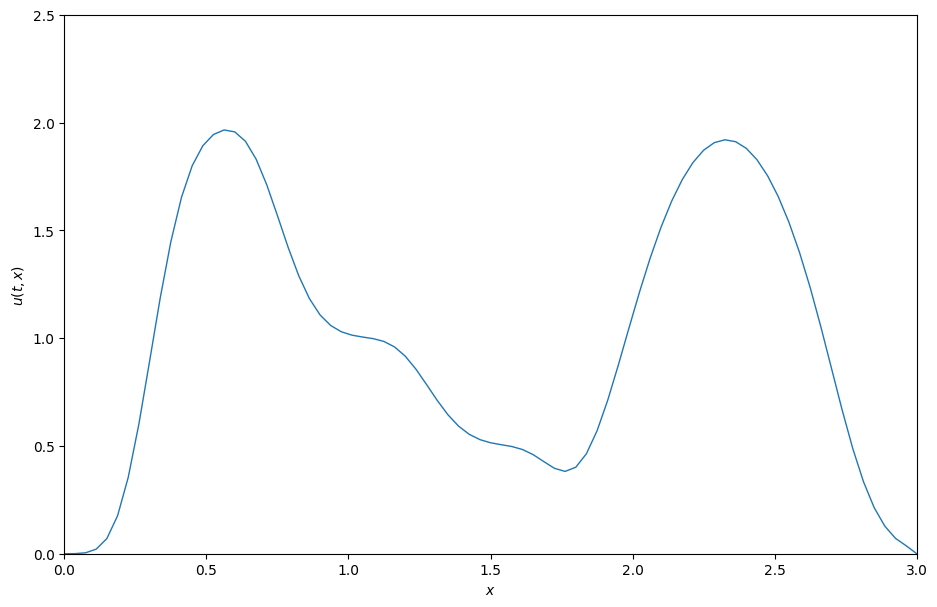

81

In [5]:
u = np.empty((nx))
uni_init_hat_especial(field=u, dx=dx, value=2., bgvalue=0, n = nx)

inicio = time.time()
for n in range(nti):
    un = u.copy()
    u[1:] = (un[1:] - (cx * dt / dx * (un[1:] - un[:-1])))

    # Condições de Contornos
    u[0] = 0.  # esquerda
    u[-1] = 0. # direita

fim = time.time()
print(f'Tempo de execução: {fim - inicio}')
print('')
print('Solução Numérica após %s segundos' % tstop)

u_up = u
uni_plot_field(u_up,xmax=L, zmax = 2.5)
u_up.size

# Devito

In [6]:
u = TimeFunction(name='u', grid=grid)
uni_init_hat_especial(field=u.data[0], dx=dx, value=2., bgvalue=0, n = nx)

eq = Eq(u.dt + cx*u.dxl)
stencil = solve(eq, u.forward)
eq_stencil = Eq(u.forward, stencil)

Operator `Kernel` ran in 0.01 s
INFO:Devito:Operator `Kernel` ran in 0.01 s


CPU times: user 39.9 ms, sys: 2.97 ms, total: 42.9 ms
Wall time: 577 ms


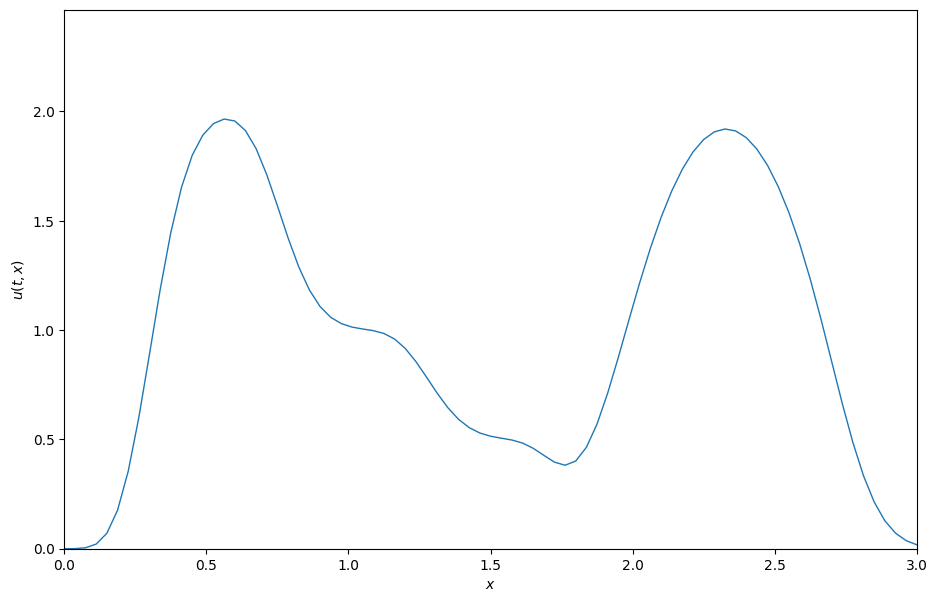

In [7]:
uni_init_hat_especial(field=u.data[0], dx=dx,bgvalue=0, n = nx)


# Condições de Contorno
bc = [Eq(u[t+1, 0], 0.)]         # u(0,t) = 0
bc += [Eq(u[t+1, nx], 0.)]       # u(L,t) = 0

# Cria um operador
op = Operator([eq_stencil] + bc)

# Aplica o operador pra um determinado número de passos temporais
%time op(time = nti, dt=dt)

uni_plot_field(u.data[0], zmax=np.max(u.data[0])+0.5)

# Analítica

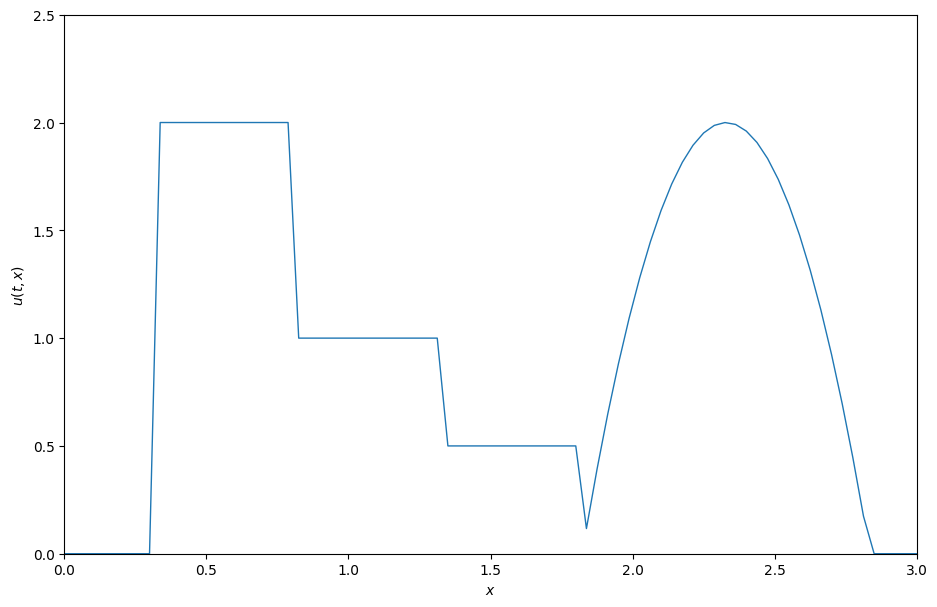

81


In [8]:
U_analytic = np.zeros(nx)
decimal_places = 10
for i in range(nx):
    x_pos = i * dx
    x_char = round(x_pos - (cx * tstop), decimal_places)  # Característica: x - ct

    if 0.0 <= x_char < 0.5:
        U_analytic[i] = 2.0
    elif 0.5 <= x_char < 1.0:
        U_analytic[i] = 1.0
    elif 1.0 <= x_char < 1.5:
        U_analytic[i] = 0.5
    elif 1.5 <= x_char < 2.5:
        # Região parabólica:
        U_analytic[i] = -8*(x_char**2) +32*x_char - 30
    else:
        U_analytic[i] = 0.0  # Background
uni_plot_field(U_analytic,zmax = 2.5)
print(U_analytic.size)

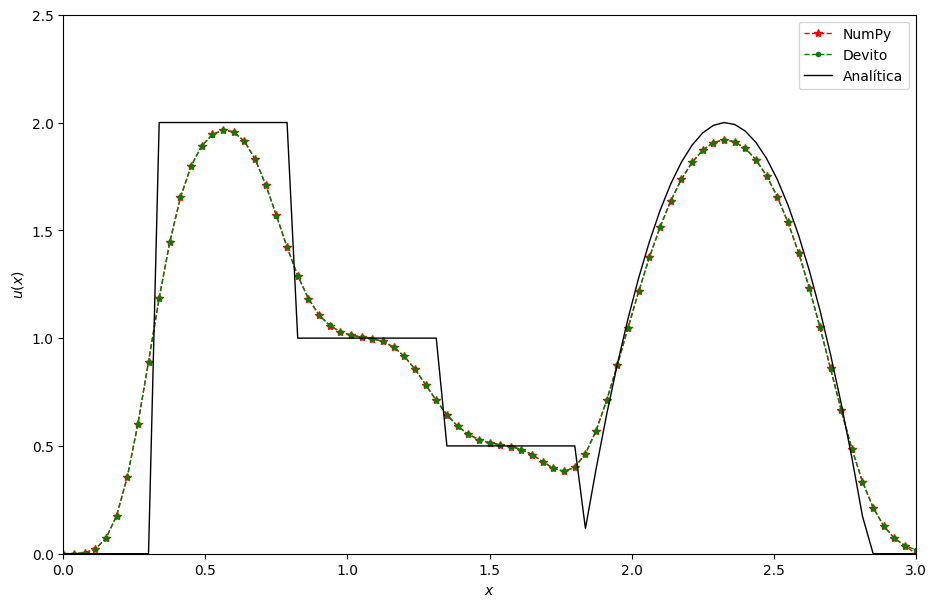

In [9]:
uni_plot_field_all(xmax = L,zmax = 2.5,fields=[u_up, u.data[0], U_analytic], labels=['NumPy', 'Devito', 'Analítica'], linestyles= [ '--', '--', '-'], markers = ['*','.',''],colors = ['red', 'green', 'black'])

In [10]:
err_rel_num = np.sqrt(np.sum((U_analytic - u_up)**2 )) / np.sqrt(np.sum((U_analytic)**2 ))
err_rel_dev = np.sqrt(np.sum((U_analytic - u.data[0])**2 )) / np.sqrt(np.sum((U_analytic)**2 ))

print(f"Erro relativo NumPy: {err_rel_num}")
print('')
print(f"Erro relativo Devito: {err_rel_dev}")

Erro relativo NumPy: 0.1740586707506957

Erro relativo Devito: 0.17414447203367192
